Using device: cuda
Loaded: {'checkpoint': True, 'stylo_cols': True, 'scaler': True, 'vt': True, 'label_encoder': True, 'doc_embs': (654, 384)}
Model loaded.
Classification report (test):

               precision    recall  f1-score   support

     Academic       0.95      1.00      0.98        20
       Normal       1.00      1.00      1.00        53
 journalistic       1.00      0.67      0.80         6
    narrative       0.91      1.00      0.95        21
philosophical       1.00      1.00      1.00        11
       poetic       1.00      0.95      0.97        20

     accuracy                           0.98       131
    macro avg       0.98      0.94      0.95       131
 weighted avg       0.98      0.98      0.98       131



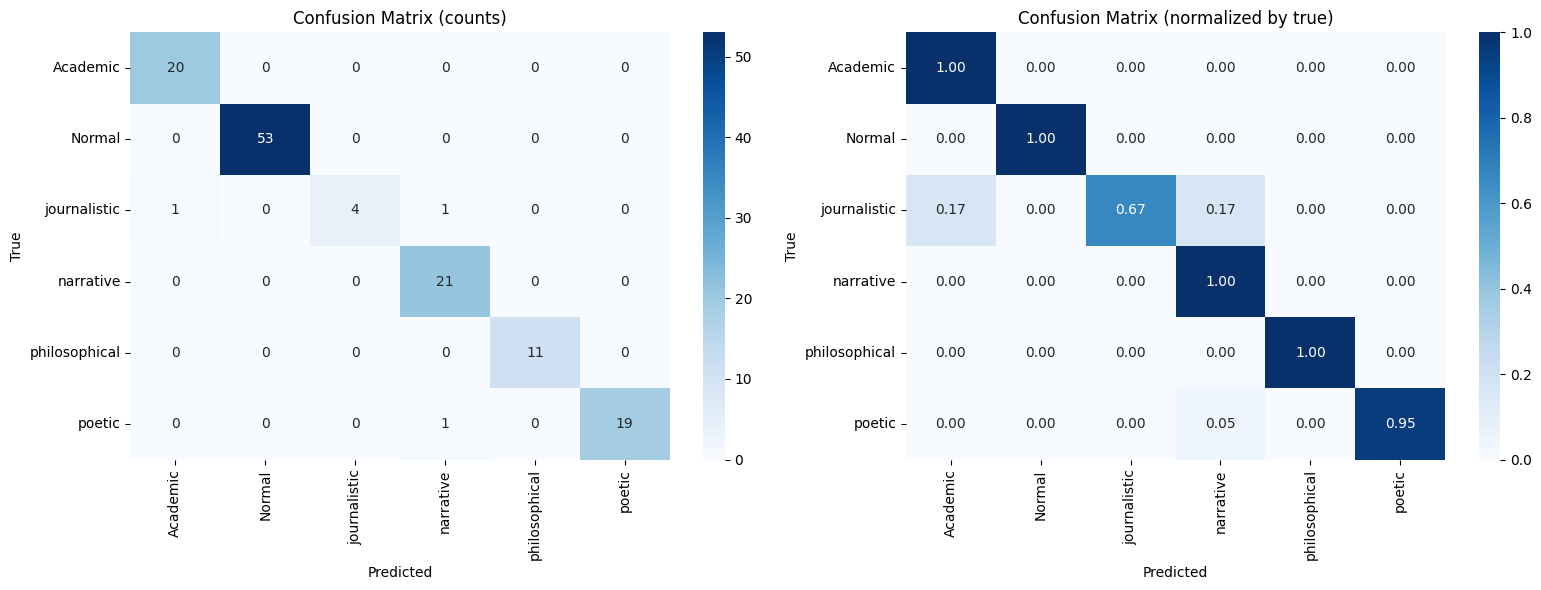

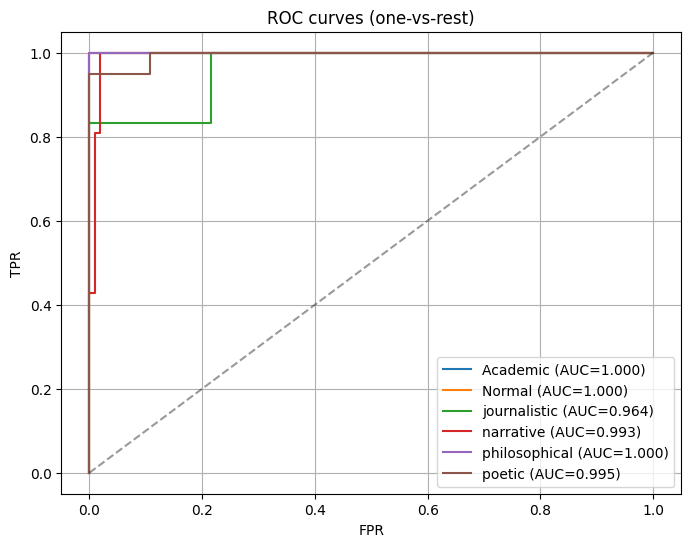

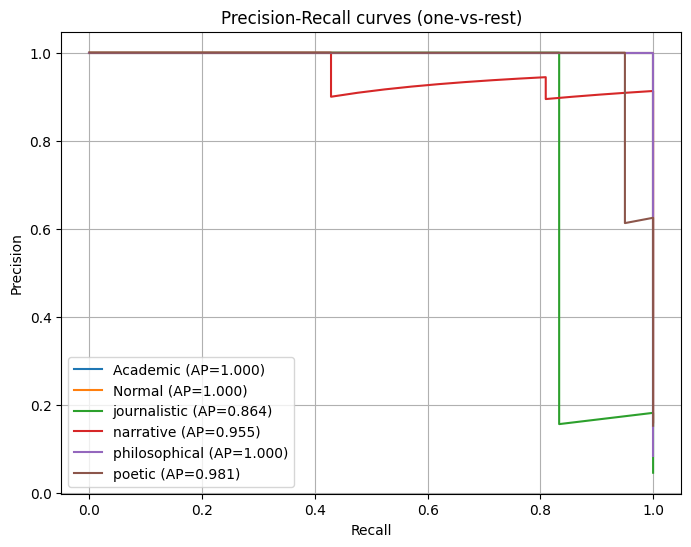

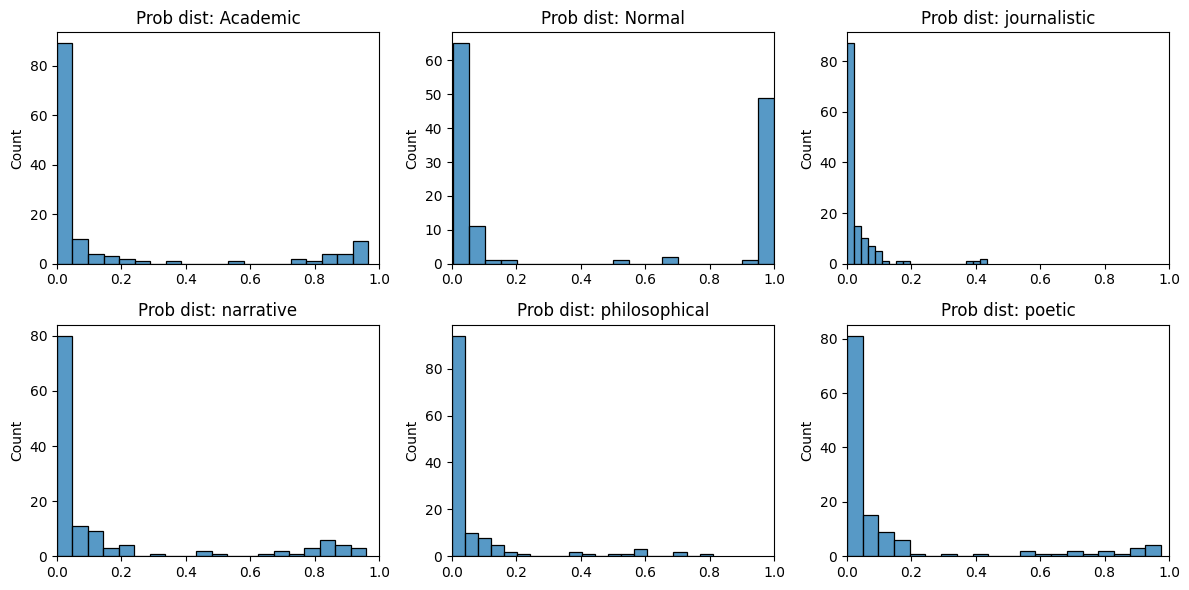

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


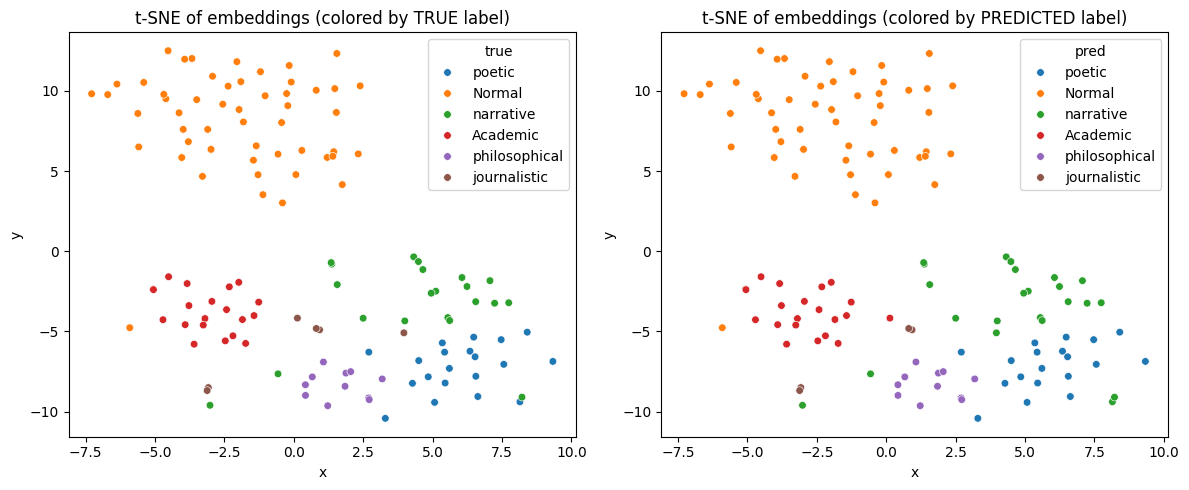

No training history file found at /content/drive/MyDrive/NLP/artifacts/training_history.pkl
All plots saved to /content/drive/MyDrive/NLP/artifacts/plots


In [ ]:

import os, math
from pathlib import Path
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc,
                             precision_recall_curve, average_precision_score)
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import torch
import torch.nn.functional as F

ARTIFACT_DIR = Path('/content/drive/MyDrive/NLP/artifacts')
PLOTS_DIR = ARTIFACT_DIR / 'plots'
os.makedirs(PLOTS_DIR, exist_ok=True)

CKPT_PATH = ARTIFACT_DIR / 'best_fusion.pt'
STYLO_COLS_PKL = ARTIFACT_DIR / 'stylo_columns.pkl'
STYLO_SCALER = ARTIFACT_DIR / 'stylo_scaler.joblib'
VT_PATH = ARTIFACT_DIR / 'stylo_var_threshold.joblib'
LABEL_ENCODER_PKL = ARTIFACT_DIR / 'label_encoder.joblib'
DOC_EMB_PATH = Path('/content/drive/MyDrive/NLP/document_embeddings.npy')
FEATURES_PARQUET = Path('/content/drive/MyDrive/NLP/stylometry_features.parquet')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)


assert CKPT_PATH.exists(), f"Checkpoint not found: {CKPT_PATH}"
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)

stylo_cols = joblib.load(STYLO_COLS_PKL) if STYLO_COLS_PKL.exists() else None
scaler = joblib.load(STYLO_SCALER) if STYLO_SCALER.exists() else None
vt = joblib.load(VT_PATH) if VT_PATH.exists() else None
label_encoder = joblib.load(LABEL_ENCODER_PKL) if LABEL_ENCODER_PKL.exists() else None
doc_embs = np.load(DOC_EMB_PATH) if DOC_EMB_PATH.exists() else None

print("Loaded:", {
    'checkpoint': CKPT_PATH.exists(),
    'stylo_cols': stylo_cols is not None,
    'scaler': scaler is not None,
    'vt': vt is not None,
    'label_encoder': label_encoder is not None,
    'doc_embs': doc_embs.shape if doc_embs is not None else None,
})


import torch.nn as nn
import torch.nn.functional as F

class FusionClassifier(nn.Module):
    def __init__(self, stylo_dim, emb_dim, hidden=512, num_classes=2, dropout=0.3):
        super().__init__()
        self.bn = nn.BatchNorm1d(stylo_dim + emb_dim)
        self.fc1 = nn.Linear(stylo_dim + emb_dim, hidden)
        self.fc2 = nn.Linear(hidden, hidden//2)
        self.out = nn.Linear(hidden//2, num_classes)
        self.drop = nn.Dropout(dropout)
    def forward(self, stylo, emb):
        x = torch.cat([stylo, emb], dim=1)
        x = self.bn(x)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        return self.out(x)

if doc_embs is None:
    raise RuntimeError("Document embeddings not found at DOC_EMB_PATH; needed for inference.")
emb_dim = doc_embs.shape[1]
if vt is None:
    raise RuntimeError("VarianceThreshold object not found; cannot determine stylo input shape.")
stylo_dim = stylo_matrix.shape[1]

num_classes = len(label_encoder.classes_) if label_encoder is not None else ckpt['model_state'][list(ckpt['model_state'].keys())[-1]].shape[0]

model = FusionClassifier(stylo_dim, emb_dim, hidden=512, num_classes=num_classes, dropout=0.3).to(DEVICE)
model.load_state_dict(ckpt['model_state'])
model.eval()
print("Model loaded.")



DATA_CSV = Path('/content/drive/MyDrive/NLP/final_dataset.csv')
if DATA_CSV.exists():
    df = pd.read_csv(DATA_CSV)
    df = df.dropna(subset=['text','label_name']).reset_index(drop=True)
    df['word_count'] = df['text'].astype(str).apply(lambda x: len(str(x).split()))
    df = df[df['word_count'] >= 5].reset_index(drop=True)

    label_encoder_local = joblib.load(LABEL_ENCODER_PKL)
    df['label_id'] = label_encoder_local.transform(df['label_name'])

    from sklearn.model_selection import train_test_split
    indices = np.arange(len(df))
    train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=SEED, stratify=df['label_id'])

    test_indices = test_idx
else:

    raise FileNotFoundError("Dataset CSV not found at DATA_CSV. Provide test_df or path.")


if FEATURES_PARQUET.exists():
    feats_all = pd.read_parquet(FEATURES_PARQUET).reset_index(drop=True)

    feats_all = feats_all.loc[:len(df)-1].reset_index(drop=True)
    stylo_full = feats_all[stylo_cols].values

    stylo_full = scaler.transform(stylo_full) if scaler is not None else stylo_full
    stylo_full = vt.transform(stylo_full) if vt is not None else stylo_full
else:
    stylo_full = None
    print("Warning: features parquet not found; stylometric columns missing for test.")

emb_full = doc_embs

test_stylo = stylo_full[test_indices] if stylo_full is not None else None
test_emb = emb_full[test_indices]
y_true = df.loc[test_indices, 'label_id'].values
y_true_names = df.loc[test_indices, 'label_name'].values

BATCH = 64
all_logits = []
all_probs = []
with torch.no_grad():
    for i in range(0, len(test_indices), BATCH):
        idxs = test_indices[i:i+BATCH]
        sty = torch.tensor(test_stylo[i:i+BATCH]).float().to(DEVICE) if test_stylo is not None else torch.zeros((len(idxs), stylo_dim), device=DEVICE)
        emb = torch.tensor(test_emb[i:i+BATCH]).float().to(DEVICE)
        logits = model(sty, emb)
        probs = F.softmax(logits, dim=1).cpu().numpy()
        all_logits.append(logits.cpu().numpy())
        all_probs.append(probs)
all_logits = np.vstack(all_logits)
all_probs = np.vstack(all_probs)
y_pred = all_logits.argmax(axis=1)

print("Classification report (test):\n")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(1,2, figsize=(16,6))
sns.heatmap(cm, annot=True, fmt='d', ax=ax[0], xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
ax[0].set_title('Confusion Matrix (counts)')
ax[0].set_xlabel('Predicted'); ax[0].set_ylabel('True')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(np.nan_to_num(cm_norm), annot=True, fmt='.2f', ax=ax[1], xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_, cmap='Blues')
ax[1].set_title('Confusion Matrix (normalized by true)')
ax[1].set_xlabel('Predicted'); ax[1].set_ylabel('True')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'confusion_matrices.png', dpi=300)
plt.show()

y_bin = label_binarize(y_true, classes=np.arange(num_classes))
if y_bin.shape[1] != num_classes:

    tmp = np.zeros((y_bin.shape[0], num_classes))
    tmp[:, :y_bin.shape[1]] = y_bin
    y_bin = tmp

fpr = dict(); tpr = dict(); roc_auc = dict()
precision = dict(); recall = dict(); ap = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    precision[i], recall[i], _ = precision_recall_curve(y_bin[:, i], all_probs[:, i])
    ap[i] = average_precision_score(y_bin[:, i], all_probs[:, i])

# Plot ROC (per class)
plt.figure(figsize=(8,6))
for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], label=f"{label_encoder.classes_[i]} (AUC={roc_auc[i]:.3f})")
plt.plot([0,1],[0,1],'k--',alpha=0.4)
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC curves (one-vs-rest)')
plt.legend(loc='lower right'); plt.grid(True)
plt.savefig(PLOTS_DIR / 'roc_curves.png', dpi=300)
plt.show()

# Plot Precision-Recall
plt.figure(figsize=(8,6))
for i in range(num_classes):
    plt.plot(recall[i], precision[i], label=f"{label_encoder.classes_[i]} (AP={ap[i]:.3f})")
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall curves (one-vs-rest)')
plt.legend(loc='lower left'); plt.grid(True)
plt.savefig(PLOTS_DIR / 'pr_curves.png', dpi=300)
plt.show()

plt.figure(figsize=(12,6))
for i in range(num_classes):
    plt.subplot(2, math.ceil(num_classes/2), i+1)
    sns.histplot(all_probs[:, i], bins=20, kde=False)
    plt.title(f"Prob dist: {label_encoder.classes_[i]}")
    plt.xlim(0,1)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'prob_histograms.png', dpi=300)
plt.show()


tsne = TSNE(n_components=2, random_state=SEED, perplexity=30, n_iter=1000)
emb_sub = test_emb
tsne_proj = tsne.fit_transform(emb_sub)
df_vis = pd.DataFrame({
    'x': tsne_proj[:,0],
    'y': tsne_proj[:,1],
    'true': [label_encoder.classes_[i] for i in y_true],
    'pred': [label_encoder.classes_[i] for i in y_pred]
})

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(data=df_vis, x='x', y='y', hue='true', palette='tab10', s=30, legend='brief')
plt.title('t-SNE of embeddings (colored by TRUE label)')
plt.subplot(1,2,2)
sns.scatterplot(data=df_vis, x='x', y='y', hue='pred', palette='tab10', s=30, legend='brief')
plt.title('t-SNE of embeddings (colored by PREDICTED label)')
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'tsne_true_pred.png', dpi=300)
plt.show()


HISTORY_PKL = ARTIFACT_DIR / 'training_history.pkl'
if HISTORY_PKL.exists():
    history = joblib.load(HISTORY_PKL)
    plt.figure(figsize=(10,4))
    plt.plot(history['train_loss'], label='train_loss')
    plt.plot(history['val_loss'], label='val_loss')
    plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
    plt.title('Training Loss History')
    plt.savefig(PLOTS_DIR / 'train_loss_history.png', dpi=300)
    plt.show()

    if 'train_f1' in history:
        plt.figure(figsize=(10,4))
        plt.plot(history['train_f1'], label='train_f1')
        plt.plot(history['val_f1'], label='val_f1')
        plt.xlabel('Epoch'); plt.ylabel('F1 (macro)'); plt.legend(); plt.grid(True)
        plt.title('F1 History')
        plt.savefig(PLOTS_DIR / 'train_f1_history.png', dpi=300)
        plt.show()
else:
    print("No training history file found at", HISTORY_PKL)

print("All plots saved to", PLOTS_DIR)